In [1]:
import ee
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

monitoring well: 100%|██████████| 2/2 [00:07<00:00,  3.83s/it]


In [4]:
gw = oc.obs["GMW000000046935001"]
print(gw)

GroundwaterObs GMW000000046935001
-----metadata------
name : GMW000000046935001 
x : 96982.07766291886 
y : 441656.1976649185 
location : 133572-26 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -6.83 
screen_bottom : -7.83 
ground_level : -5.63 
tube_top : -5.73 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2021-04-08 23:00:00  -6.43     2  Gemeten   hand
2021-05-11 23:00:00  -6.39     2  Gemeten   hand
2021-06-09 23:00:00  -6.56     2  Gemeten   hand
2021-07-15 23:00:00  -6.62     2  Gemeten   hand
2021-08-09 23:00:00  -6.56     2  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-16 05:07:01  -6.39     2           diver
2026-03-16 09:07:03  -6.41     2           diver
2026-03-16 13:07:04  -6.42     2           diver
2026-03-16 17:07:06  -6.42     2           diver
2026-03-16 21:07:07  -6.42     2           diver

[2212 rows x 4 columns

In [5]:
project = 'afstuderen-481613'

import os
initialized = False

# Prefer service account if GOOGLE_APPLICATION_CREDENTIALS is set
key_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')
if key_path and os.path.exists(key_path):
    try:
        from oauth2client.service_account import ServiceAccountCredentials
        creds = ServiceAccountCredentials.from_json_keyfile_name(key_path, scopes=['https://www.googleapis.com/auth/earthengine'])
        ee.Initialize(project=project, credentials=creds)
        initialized = True
    except Exception as e:
        print('Service account init failed:', e)

# Fall back to user authentication (interactive) or existing credentials
if not initialized:
    try:
        ee.Initialize(project=project)
        initialized = True
    except Exception as e:
        try:
            ee.Authenticate()
            ee.Initialize(project=project)
            initialized = True
        except Exception as e2:
            raise RuntimeError('Earth Engine initialization failed. Run `earthengine authenticate` or set GOOGLE_APPLICATION_CREDENTIALS to a service account key.') from e2

roi = ee.Geometry.Rectangle(extent_to_ee('ndvi'))

In [6]:
# ---------- helpers ----------
def ee_fc_to_df(fc, props=("date", "ndvi", "n_pixels")):
    feats = fc.getInfo()["features"]
    rows = []
    for f in feats:
        p = f.get("properties", {})
        if all(p.get(k) is not None for k in props):
            rows.append({k: p.get(k) for k in props})
    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["ndvi"] = df["ndvi"].astype(float)
        df["n_pixels"] = df["n_pixels"].astype(float)
        df = df.sort_values("date").reset_index(drop=True)
    return df


def reduce_ndvi_mean_and_count(img, roi, scale):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13,
    )
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")
    return ee.Feature(None, {
        "date": date,
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


def ndvi_timeseries(collection_id, roi, start_date, end_date, scale,
                    add_ndvi_fn, mask_fn=None, extra_filter=None):

    col = (ee.ImageCollection(collection_id)
           .filterBounds(roi)
           .filterDate(start_date, end_date))

    if extra_filter is not None:
        col = col.filter(extra_filter)
    if mask_fn is not None:
        col = col.map(mask_fn)

    col = col.map(add_ndvi_fn)

    fc = col.map(lambda img: reduce_ndvi_mean_and_count(img, roi, scale))
    df = ee_fc_to_df(ee.FeatureCollection(fc))
    return df


# ---------- Sentinel-2 specifics ----------
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (scl.neq(3)
            .And(scl.neq(7))
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(img.normalizedDifference(["B8", "B4"]).rename("NDVI"))


# ---------- Run Sentinel‑2 only ----------
df_s2 = ndvi_timeseries(
    collection_id="COPERNICUS/S2_SR_HARMONIZED",
    roi=roi,
    start_date=NDVI_START_DATE,
    end_date=NDVI_END_DATE,
    scale=10,
    add_ndvi_fn=add_ndvi_s2,
    mask_fn=mask_s2_clouds,
    extra_filter=ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30),
)

df_s2

,date,ndvi,n_pixels
0,2021-04-20,0.393626,95572.0
1,2021-04-20,0.385984,95710.0
2,2021-05-30,0.534670,119336.0
3,2021-05-30,0.525492,119462.0
4,2021-06-09,0.513945,89658.0
...,...,...,...
130,2025-09-01,0.533492,100610.0
131,2025-12-25,0.406802,137593.0
132,2025-12-25,0.423210,138095.0
133,2025-12-30,0.449057,138195.0


,count
status,
kept,97
removed,38


,date,ndvi,n_pixels
0,2021-04-20,0.393626,95572.0
1,2021-04-20,0.385984,95710.0
2,2021-06-09,0.513945,89658.0
3,2021-08-03,0.243233,1201.0
4,2021-09-07,0.531032,78746.0
5,2021-11-21,0.545338,64973.0
6,2021-12-16,0.469560,90688.0
7,2021-12-16,0.563803,93576.0
8,2022-02-14,0.445957,13984.0
9,2022-03-06,0.424603,90170.0


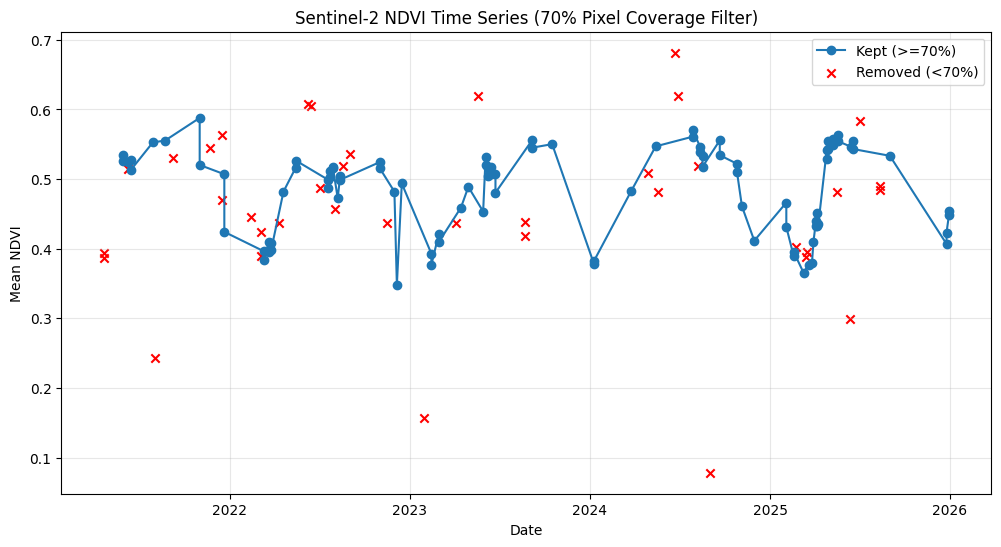

In [7]:
# Compute expected number of 10m pixels in ROI
roi_area_m2 = roi.area().getInfo()
pixel_area = 10 * 10
expected_pixels = roi_area_m2 / pixel_area

# 70% threshold
threshold = expected_pixels * 0.70

# Apply threshold
df = df_s2.copy()
df["min_required"] = threshold
df["status"] = np.where(df["n_pixels"] >= df["min_required"], "kept", "removed")

df_kept = df[df["status"] == "kept"].reset_index(drop=True)
df_removed = df[df["status"] == "removed"].reset_index(drop=True)

# Summary
summary = df.groupby("status").size().to_frame("count")
display(summary)

# Show removed rows
display(df_removed[["date", "ndvi", "n_pixels"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_kept["date"], df_kept["ndvi"], marker="o", label="Kept (>=70%)")

if len(df_removed) > 0:
    plt.scatter(df_removed["date"], df_removed["ndvi"], marker="x", color="red", label="Removed (<70%)")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Sentinel‑2 NDVI Time Series (70% Pixel Coverage Filter)")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# ================================
# Maandelijkse aggregatie (nadat we pixels hebben gefilterd)
# ================================

# NDVI: gebruik alleen de "kept" beelden met voldoende dekking, filter op datum,
# en aggregeer dan naar maandelijks gemiddelde
df_s2_filtered = df_kept[
    (df_kept["date"] >= NDVI_START_DATE) & 
    (df_kept["date"] <= NDVI_END_DATE)
].copy()

df_s2_copy = df_s2_filtered.copy()
df_s2_copy["year_month"] = df_s2_copy["date"].dt.to_period("M")
df_s2_month = df_s2_copy.groupby("year_month").agg({
    "ndvi": "mean",
    "date": "first"
}).reset_index(drop=True)
df_s2_month = df_s2_month.rename(columns={"ndvi": "ndvi_month"})
print(f"NDVI data gefilterd (na pixelfilter): {len(df_kept)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} maanden)")
print(f"NDVI data gefilterd: {len(df_s2)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} maanden)")

# GW: filter op NDVI_START_DATE tot NDVI_END_DATE, haal data uit GroundwaterObs en aggregeer naar maandelijks
gw_filtered = gw[(gw.index >= NDVI_START_DATE) & (gw.index <= NDVI_END_DATE)].copy()

gw_month_df = gw_filtered.reset_index()
gw_month_df.columns = ["peil_datum_tijd", "peil_waarde_cm", "flag", "comment", "origin"]
gw_month_df["peil_datum_tijd"] = pd.to_datetime(gw_month_df["peil_datum_tijd"])
gw_month_df["year_month"] = gw_month_df["peil_datum_tijd"].dt.to_period("M")
gw_month = gw_month_df.groupby("year_month").agg({
    "peil_waarde_cm": "mean",
    "peil_datum_tijd": "first"
}).reset_index(drop=True)
gw_month = gw_month.rename(columns={"peil_waarde_cm": "gw_month"})

print(f"GW data gefilterd: {len(gw)} -> {len(gw_filtered)} records ({len(gw_month)} maanden)")

# Zet date kolom om naar datetime voor latere matching
gw_month["date"] = pd.to_datetime(gw_month["peil_datum_tijd"])
df_s2_month["date"] = pd.to_datetime(df_s2_month["date"])

display(df_s2_month)
display(gw_month)

NDVI data gefilterd (na pixelfilter): 97 -> 97 records (35 maanden)
NDVI data gefilterd: 135 -> 97 records (35 maanden)
GW data gefilterd: 2212 -> 1796 records (35 maanden)


,ndvi_month,date
0,0.530081,2021-05-30
1,0.521325,2021-06-09
2,0.552712,2021-07-29
3,0.555448,2021-08-23
4,0.554126,2021-11-01
5,0.465595,2021-12-21
6,0.398489,2022-03-11
7,0.482072,2022-04-20
8,0.521651,2022-05-15
9,0.505988,2022-07-19


,gw_month,peil_datum_tijd,date
0,-6.430000,2021-04-08 23:00:00,2021-04-08 23:00:00
1,-6.390000,2021-05-11 23:00:00,2021-05-11 23:00:00
2,-6.560000,2021-06-09 23:00:00,2021-06-09 23:00:00
3,-6.620000,2021-07-15 23:00:00,2021-07-15 23:00:00
4,-6.560000,2021-08-09 23:00:00,2021-08-09 23:00:00
5,-6.740000,2021-09-06 06:47:00,2021-09-06 06:47:00
6,-6.450000,2021-10-21 13:16:00,2021-10-21 13:16:00
7,-6.490000,2021-11-11 10:37:00,2021-11-11 10:37:00
8,-6.220000,2021-12-08 13:01:00,2021-12-08 13:01:00
9,-6.360000,2022-01-07 13:52:00,2022-01-07 13:52:00


Periode: 2021-04-1 tot 2025-12-31
Verwacht aantal maanden: 57

--- Data beschikbaarheid ---
Werkelijke maanden in analyse: 48
Waarvan NDVI geïnterpoleerd: 13 keer
Waarvan GW geïnterpoleerd: 14 keer


,date,ndvi_month,gw_month,ndvi_interpolated,gw_interpolated
0,2021-05-30 00:00:00,0.530081,-6.390000,False,False
1,2021-06-09 00:00:00,0.521325,-6.560000,False,False
2,2021-07-29 00:00:00,0.552712,-6.620000,False,False
3,2021-08-23 00:00:00,0.555448,-6.560000,False,False
4,2021-09-06 06:47:00,0.555007,-6.740000,True,False
5,2021-10-21 13:16:00,0.554566,-6.450000,True,False
6,2021-11-01 00:00:00,0.554126,-6.490000,False,False
7,2021-12-21 00:00:00,0.465595,-6.220000,False,False
8,2022-01-07 13:52:00,0.443226,-6.360000,True,False
9,2022-02-07 11:02:00,0.420858,-6.240000,True,False



OLS LINEAIRE REGRESSIE RESULTATEN
                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     12.18
Date:                Tue, 17 Mar 2026   Prob (F-statistic):            0.00107
Time:                        13:49:06   Log-Likelihood:                 77.699
No. Observations:                  48   AIC:                            -151.4
Df Residuals:                      46   BIC:                            -147.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

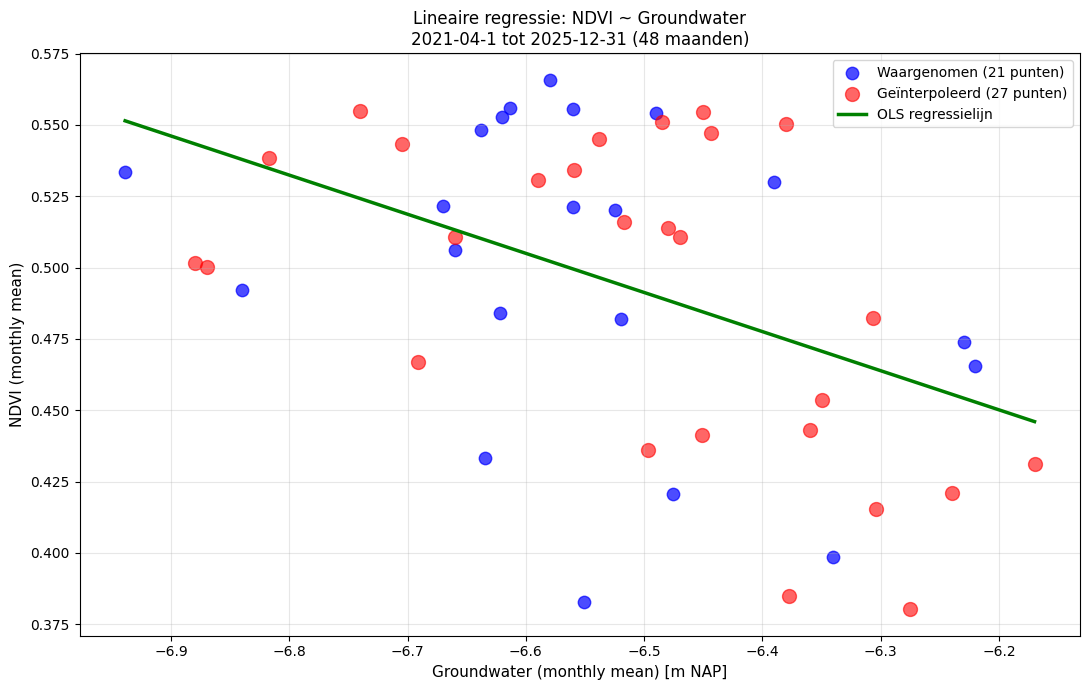

In [9]:
# ================================
# Voorbereiding en merging
# ================================

# Bereken het aantal verwachte maanden uit NDVI_START_DATE en NDVI_END_DATE
start_dt = pd.to_datetime(NDVI_START_DATE)
end_dt = pd.to_datetime(NDVI_END_DATE)
expected_months = (end_dt.year - start_dt.year) * 12 + (end_dt.month - start_dt.month) + 1

print(f"Periode: {NDVI_START_DATE} tot {NDVI_END_DATE}")
print(f"Verwacht aantal maanden: {expected_months}")

# Zet beide dates om naar YYYY-MM formaat voor matching
gw_month["date_period"] = gw_month["date"].dt.to_period("M")
df_s2_month["date_period"] = df_s2_month["date"].dt.to_period("M")

# Merge NDVI en GW op period
df_month = (
    df_s2_month.merge(gw_month[["gw_month", "date_period", "date"]],
                      left_on="date_period", right_on="date_period", how="outer")
    .sort_values("date_x")
    .reset_index(drop=True)
)

# Vul datumkolom
df_month["date"] = df_month["date_x"].fillna(df_month["date_y"])
df_month = df_month.drop(columns=["date_x", "date_y"])

# BELANGRIJK: Sorteer op datum VOORDAT interpolatie
df_month = df_month.sort_values("date").reset_index(drop=True)

# ================================
# Interpolatie
# ================================

# Track welke waarden geïnterpoleerd zijn VOORDAT we interpoleren
df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()
df_month["gw_interpolated"] = df_month["gw_month"].isna()

# Interpoleer beide kolommen (nu correct gesorteerd op datum)
df_month["ndvi_month"] = df_month["ndvi_month"].interpolate(method="linear")
df_month["gw_month"] = df_month["gw_month"].interpolate(method="linear")

# Verwijder ALLEEN de edges met NaN (voor en na de reeks)
df_month = df_month.dropna(subset=["ndvi_month", "gw_month"]).reset_index(drop=True)

actual_months = len(df_month)

print(f"\n--- Data beschikbaarheid ---")
print(f"Werkelijke maanden in analyse: {actual_months}")
print(f"Waarvan NDVI geïnterpoleerd: {df_month['ndvi_interpolated'].sum()} keer")
print(f"Waarvan GW geïnterpoleerd: {df_month['gw_interpolated'].sum()} keer")

display(df_month[["date", "ndvi_month", "gw_month", "ndvi_interpolated", "gw_interpolated"]])

# ================================
# 1) Data voorbereiden
# ================================

X = df_month[["gw_month"]]     # onafhankelijke variabele
X = sm.add_constant(X)         # voeg intercept toe
y = df_month["ndvi_month"]     # afhankelijke variabele

# ================================
# 2) OLS-regressie fitten
# ================================

ols_model = sm.OLS(y, X).fit()

print("\n==============================================")
print("OLS LINEAIRE REGRESSIE RESULTATEN")
print("==============================================")
print(ols_model.summary())

# ================================
# 3) Scatterplot + regressielijn
# ================================

plt.figure(figsize=(11, 7))

is_obs = ~(df_month["ndvi_interpolated"] | df_month["gw_interpolated"])

plt.scatter(df_month.loc[is_obs, "gw_month"], df_month.loc[is_obs, "ndvi_month"],
            label=f"Waargenomen ({is_obs.sum()} punten)", marker="o", s=80, alpha=0.7, color="blue")

plt.scatter(df_month.loc[~is_obs, "gw_month"], df_month.loc[~is_obs, "ndvi_month"],
            label=f"Geïnterpoleerd ({(~is_obs).sum()} punten)", marker="o", s=100, color="red", alpha=0.6)

# Regressielijn
xline = np.linspace(df_month["gw_month"].min(), df_month["gw_month"].max(), 100)
xline_const = sm.add_constant(xline)
plt.plot(xline, ols_model.predict(xline_const), color="green", linewidth=2.5, label="OLS regressielijn")

plt.xlabel("Groundwater (monthly mean) [m NAP]", fontsize=11)
plt.ylabel("NDVI (monthly mean)", fontsize=11)
plt.title(f"Lineaire regressie: NDVI ~ Groundwater\n{NDVI_START_DATE} tot {NDVI_END_DATE} ({actual_months} maanden)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### ARDL(1,1) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     12.44
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.45e-06
Time:                        13:49:06   Log-Likelihood:                 84.959
No. Observations:                  47   AIC:                            -161.9
Df Residuals:                      43   BIC:                            -154.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1806      0.240     -0.751      0.456      -0.665       0.304
gw_month      -0.1290      0.051     -2.509      0.016      -0.233      -0.025
gw_lag1        0.0687      0.054      1.274      0.209      -0.040       0.177
ndvi_lag1      0.5652      0.129      4.396      0.000       0.306       0.824
==============================================================================
Omnibus:                        4.685   Durbin-Watson:                   1.664
Prob(Omnibus):                  0.096   Jarque-Bera (JB):                3.856
Skew:                          -0.694   Prob(JB):                        0.145
Kurtosis:                       3.205   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

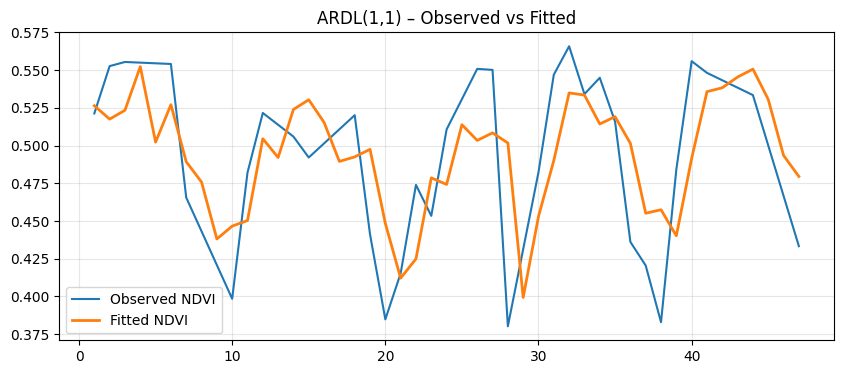

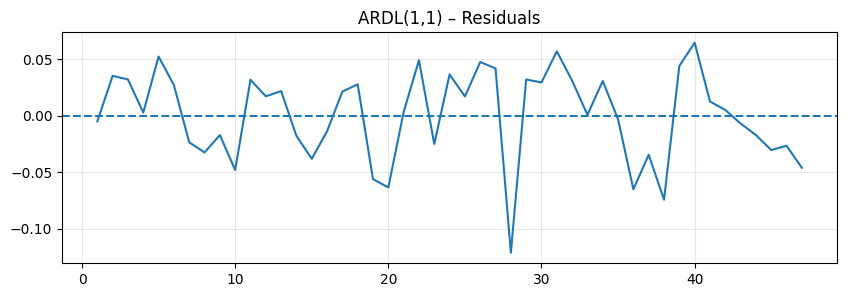

### ARDL(2,2) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     10.19
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.39e-06
Time:                        13:49:07   Log-Likelihood:                 87.309
No. Observations:                  46   AIC:                            -162.6
Df Residuals:                      40   BIC:                            -151.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.246      0.006      0.996      -0.495       0.498
gw_month      -0.0936      0.050     -1.861      0.070      -0.195       0.008
gw_lag1       -0.0257      0.067     -0.381      0.705      -0.162       0.111
gw_lag2        0.0781      0.052      1.498      0.142      -0.027       0.183
ndvi_lag1      0.7344      0.146      5.028      0.000       0.439       1.030
ndvi_lag2     -0.2852      0.147     -1.935      0.060      -0.583       0.013
==============================================================================
Omnibus:                        5.353   Durbin-Watson:                   2.235
Prob(Omnibus):                  0.069   Jarque-Bera (JB):                4.192
Skew:                          -0.690   Prob(JB):                        0.123
Kurtosis:                       3.531   Cond. No.                         494.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

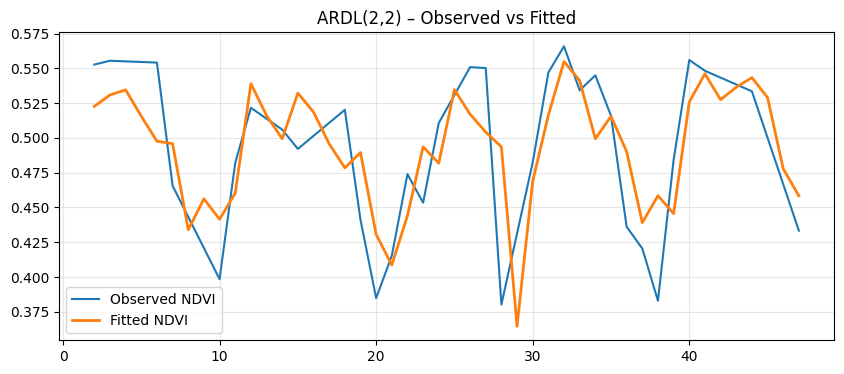

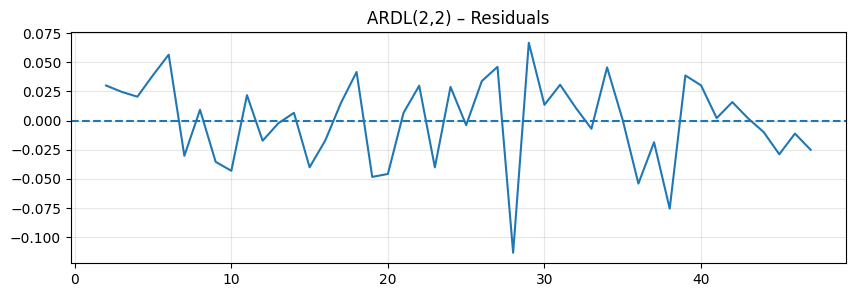

### ARDL(3,3) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     8.654
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.94e-06
Time:                        13:49:07   Log-Likelihood:                 88.843
No. Observations:                  45   AIC:                            -161.7
Df Residuals:                      37   BIC:                            -147.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2903      0.267      1.087      0.284      -0.251       0.832
gw_month      -0.0558      0.050     -1.114      0.273      -0.157       0.046
gw_lag1       -0.0409      0.065     -0.629      0.533      -0.173       0.091
gw_lag2       -0.0301      0.065     -0.464      0.645      -0.162       0.101
gw_lag3        0.1230      0.055      2.240      0.031       0.012       0.234
ndvi_lag1      0.6150      0.152      4.056      0.000       0.308       0.922
ndvi_lag2     -0.1748      0.178     -0.980      0.334      -0.536       0.187
ndvi_lag3     -0.0839      0.148     -0.569      0.573      -0.383       0.215
==============================================================================
Omnibus:                        6.344   Durbin-Watson:                   2.171
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                5.189
Skew:                          -0.781   Prob(JB):                       0.0747
Kurtosis:                       3.573   Cond. No.                         642.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

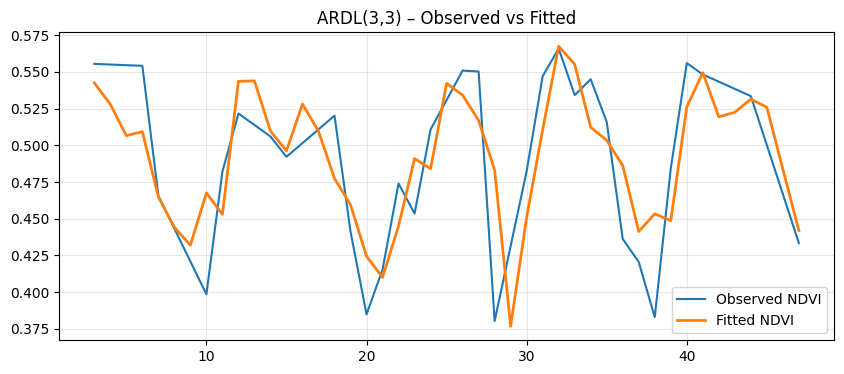

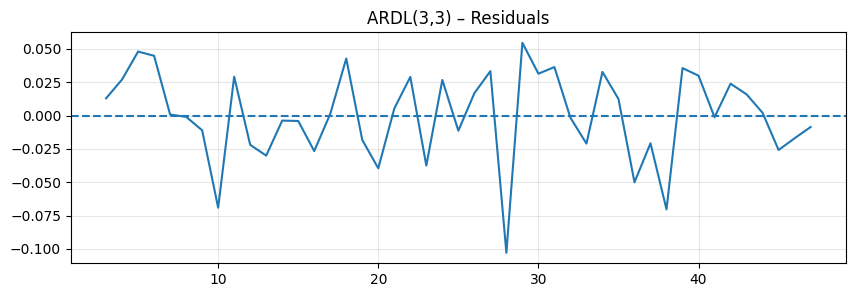

In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

results = []
metrics = []

for p in [1, 2, 3]:
    q = p  # ARDL(p,p)

    df_lagged = df_month.sort_index().copy()

    # NDVI lags
    for i in range(1, p+1):
        df_lagged[f"ndvi_lag{i}"] = df_lagged["ndvi_month"].shift(i)

    # GW lags
    for j in range(1, q+1):
        df_lagged[f"gw_lag{j}"] = df_lagged["gw_month"].shift(j)

    # Drop missings
    df_lagged = df_lagged.dropna()

    # ===== BELANGRIJK: huidige GW_t toevoegen =====
    lag_cols = ["gw_month"] + \
               [f"gw_lag{j}" for j in range(1, q+1)] + \
               [f"ndvi_lag{i}" for i in range(1, p+1)]

    X = sm.add_constant(df_lagged[lag_cols])
    y = df_lagged["ndvi_month"]

    model = sm.OLS(y, X).fit()
    results.append((p, q, model))

    summary_text = model.summary().as_text()
    display(Markdown(f"### ARDL({p},{q}) Summary\n```\n{summary_text}\n```"))

    metrics.append({
        "Model": f"ARDL({p},{q})",
        "R²": round(model.rsquared, 3),
        "Adj R²": round(model.rsquared_adj, 3),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2)
    })

    plt.figure(figsize=(10, 4))
    plt.plot(df_lagged.index, y, label="Observed NDVI")
    plt.plot(df_lagged.index, model.fittedvalues, label="Fitted NDVI", linewidth=2)
    plt.title(f"ARDL({p},{q}) – Observed vs Fitted")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(df_lagged.index, model.resid)
    plt.axhline(0, linestyle="--")
    plt.title(f"ARDL({p},{q}) – Residuals")
    plt.grid(alpha=0.3)
    plt.show()

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     17.60
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.42e-06
Time:                        13:49:07   Log-Likelihood:                 84.088
No. Observations:                  47   AIC:                            -162.2
Df Residuals:                      44   BIC:                            -156.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3009      0.223     -1.352      0.1

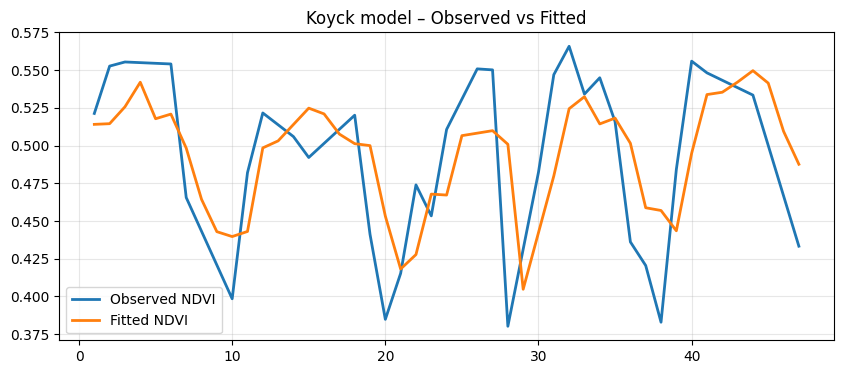

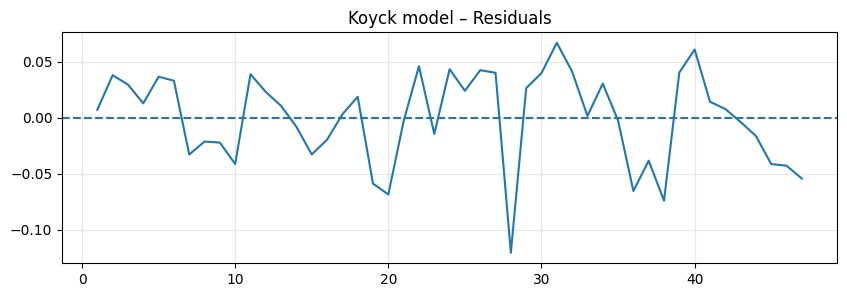

In [11]:
df_koyck = df_month.sort_index().copy()

df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "gw_month", "ndvi_month"])

y = df_koyck["ndvi_month"]
X = df_koyck[["gw_month", "ndvi_lag1"]]   # huidige GW + NDVI lag
X = sm.add_constant(X)

koyck_model = sm.OLS(y, X).fit()
print(koyck_model.summary())

plt.figure(figsize=(10,4))
plt.plot(df_koyck.index, y, label="Observed NDVI", linewidth=2)
plt.plot(df_koyck.index, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck model – Observed vs Fitted")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(df_koyck.index, koyck_model.resid)
plt.axhline(0, linestyle="--")
plt.title("Koyck model – Residuals")
plt.grid(alpha=0.3)
plt.show()

In [12]:
summary_rows = []

# ============================================

# 1) LINEAIRE REGRESSIE

# ============================================

summary_rows.append({

    "Model": "Linear Regression",

    "R²": ols_model.rsquared,

    "Adj R²": ols_model.rsquared_adj,

    "Prob(F)": ols_model.f_pvalue,

    "F-statistic": ols_model.fvalue,

    "AIC": ols_model.aic,

    "BIC": ols_model.bic

})

# ============================================

# 2) ARDL MODELLEN

# ============================================

for (p, q, model) in results:

    summary_rows.append({

        "Model": f"ARDL({p},{q})",

        "R²": model.rsquared,

        "Adj R²": model.rsquared_adj,

        "Prob(F)": model.f_pvalue,

        "F-statistic": model.fvalue,

        "AIC": model.aic,

        "BIC": model.bic

    })

# ============================================

# 3) KOYCK

# ============================================

summary_rows.append({

    "Model": "Koyck Transformation",

    "R²": koyck_model.rsquared,

    "Adj R²": koyck_model.rsquared_adj,

    "Prob(F)": koyck_model.f_pvalue,

    "F-statistic": koyck_model.fvalue,

    "AIC": koyck_model.aic,

    "BIC": koyck_model.bic

})

summary_df = pd.DataFrame(summary_rows).round(4)

display(summary_df)

,Model,R²,Adj R²,Prob(F),F-statistic,AIC,BIC
0,Linear Regression,0.2094,0.1922,0.0011,12.1848,-151.3974,-147.6550
1,"ARDL(1,1)",0.4646,0.4273,0.0000,12.4389,-161.9178,-154.5172
2,"ARDL(2,2)",0.5603,0.5053,0.0000,10.1929,-162.6179,-151.6460
3,"ARDL(3,3)",0.6208,0.5491,0.0000,8.6545,-161.6852,-147.2319
4,Koyck Transformation,0.4444,0.4192,0.0000,17.5975,-162.1763,-156.6258


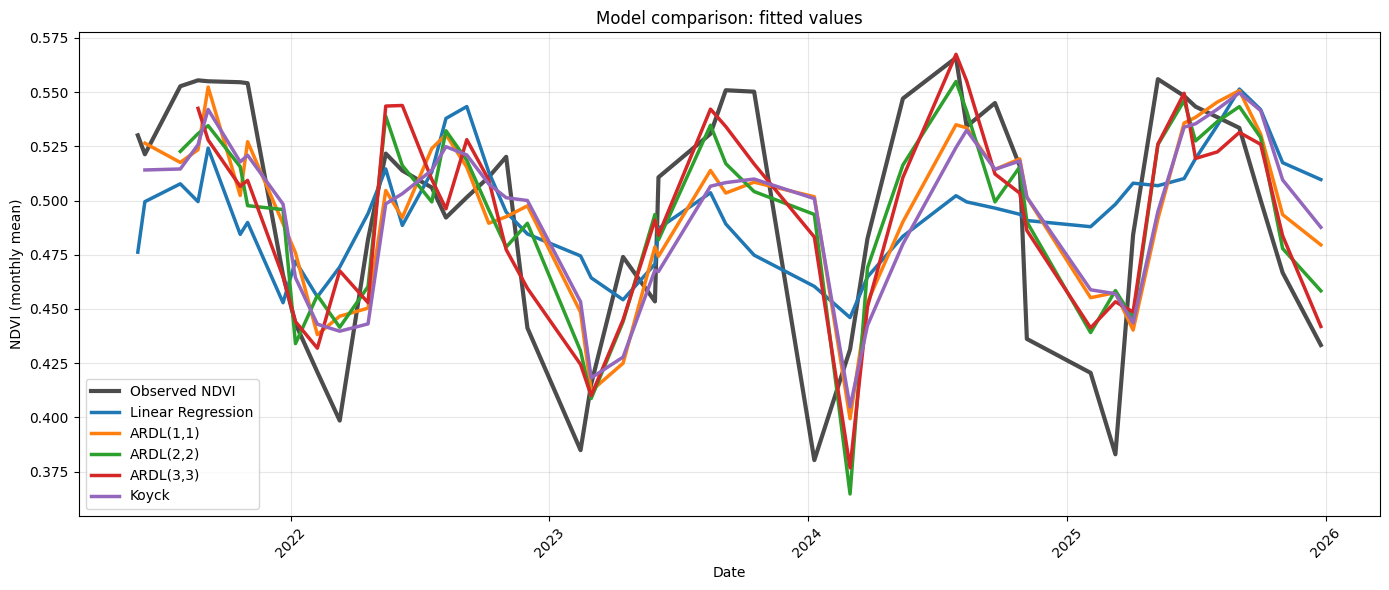

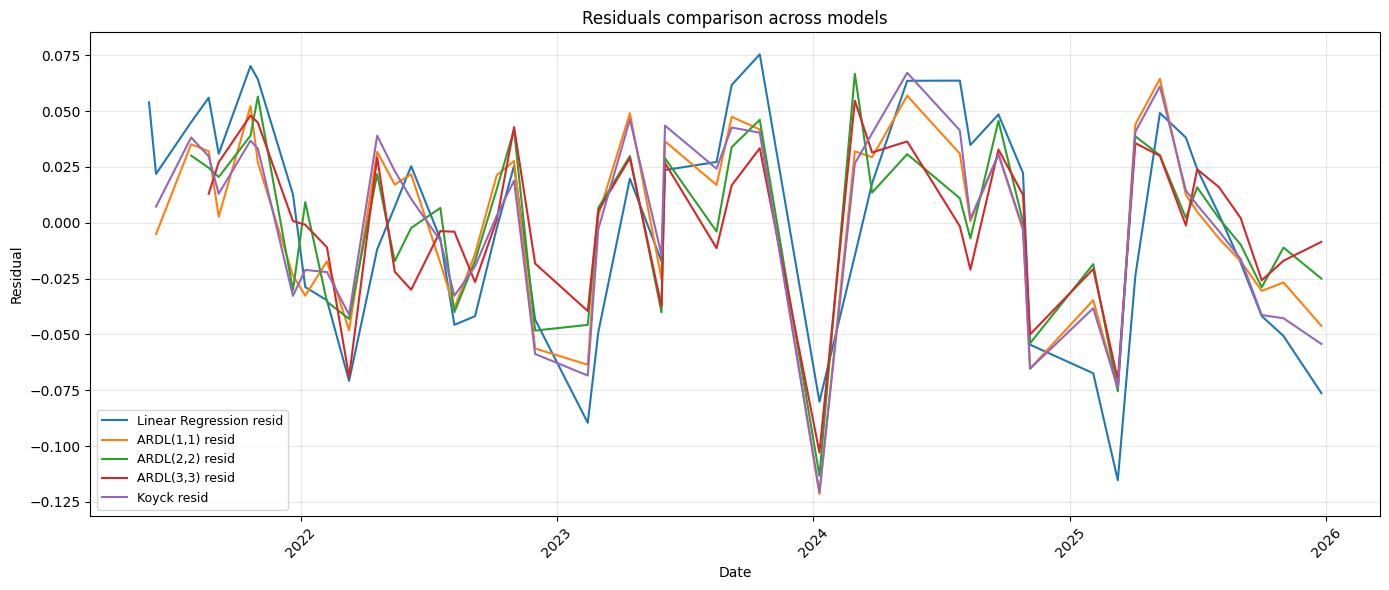


Model comparison summary:


,Model,R²,Adj R²,Prob(F),F-statistic,AIC,BIC
0,Linear Regression,0.2094,0.1922,0.0011,12.1848,-151.3974,-147.6550
1,"ARDL(1,1)",0.4646,0.4273,0.0000,12.4389,-161.9178,-154.5172
2,"ARDL(2,2)",0.5603,0.5053,0.0000,10.1929,-162.6179,-151.6460
3,"ARDL(3,3)",0.6208,0.5491,0.0000,8.6545,-161.6852,-147.2319
4,Koyck Transformation,0.4444,0.4192,0.0000,17.5975,-162.1763,-156.6258


In [13]:
# ================================
# Combined fit & residual comparison
# ================================

# Prepare color palette
colors = {
    'ols': '#1f77b4',
    'ardl_1_1': '#ff7f0e',
    'ardl_2_2': '#2ca02c',
    'ardl_3_3': '#d62728',
    'koyck': '#9467bd'
}

# combined fitted plot
fig, ax = plt.subplots(figsize=(14,6))

# observed NDVI line
ax.plot(df_month['date'], df_month['ndvi_month'], color='black', linewidth=3, alpha=0.7, label='Observed NDVI')

# OLS fit
ols_dates = df_month.loc[ols_model.fittedvalues.index, 'date'].values
ax.plot(ols_dates, ols_model.fittedvalues.values, color=colors['ols'], linewidth=2.5, label='Linear Regression')

# ARDL fits
for p,q,model in results:
    key = f'ardl_{p}_{q}'
    dates = df_month.loc[model.fittedvalues.index, 'date'].values
    ax.plot(dates, model.fittedvalues.values, color=colors[key], linewidth=2.5, label=f'ARDL({p},{q})')

# Koyck fit
koyck_dates = df_koyck.loc[koyck_model.fittedvalues.index, 'date'].values
ax.plot(koyck_dates, koyck_model.fittedvalues.values, color=colors['koyck'], linewidth=2.5, label='Koyck')

ax.set_xlabel('Date')
ax.set_ylabel('NDVI (monthly mean)')
ax.set_title('Model comparison: fitted values')
ax.legend(loc='best', fontsize=10)
ax.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# residual comparison
fig, ax = plt.subplots(figsize=(14,6))

# OLS residuals
ols_dates = df_month.loc[ols_model.resid.index, 'date'].values
ax.plot(ols_dates, ols_model.resid.values, color=colors['ols'], linewidth=1.5, label='Linear Regression resid')

for p,q,model in results:
    key = f'ardl_{p}_{q}'
    dates = df_month.loc[model.resid.index, 'date'].values
    ax.plot(dates, model.resid.values, color=colors[key], linewidth=1.5, label=f'ARDL({p},{q}) resid')

# Koyck residuals
koyck_dates = df_koyck.loc[koyck_model.resid.index, 'date'].values
ax.plot(koyck_dates, koyck_model.resid.values, color=colors['koyck'], linewidth=1.5, label='Koyck resid')

ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.set_title('Residuals comparison across models')
ax.legend(fontsize=9)
ax.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# display existing summary table again for reference
print('\nModel comparison summary:')
display(summary_df)

In [19]:
# ────────────────────────────────────────────────
#  Laad de gesimuleerde grondwaterstanden (forecast)
# ────────────────────────────────────────────────
import pandas as pd

path = r"C:\afstuderen\python_projects\beroepsproduct\three_scenarios_forecast.csv"

# Lees de CSV met de datum als index (eerste kolom zonder header-naam)
df_forecast = pd.read_csv(
    path,
    index_col=0,           # de eerste kolom (datums) wordt de index
    parse_dates=True       # probeer automatisch datums te parsen
)

# Hernoem kolommen naar duidelijke namen (past bij je eerdere code)
df_forecast = df_forecast.rename(columns={
    'Mean':   'gw_mean_sim',
    'Upper':  'gw_upper_95',
    'Lower':  'gw_lower_5'
})

# Zorg ervoor dat de index écht datetime is
if not pd.api.types.is_datetime64_any_dtype(df_forecast.index):
    df_forecast.index = pd.to_datetime(df_forecast.index)

# Controleer of alles goed is ingelezen
print("Bestand succesvol ingelezen!")
print("Vorm van de DataFrame:", df_forecast.shape)
print("Index type:", df_forecast.index.dtype)
print("Eerste datum:", df_forecast.index.min())
print("Laatste datum:", df_forecast.index.max())
print("Kolommen:", df_forecast.columns.tolist())

# Toon de eerste 10 rijen + laatste 5 rijen
print("\nVoorbeeld data (eerste 10 dagen):")
display(df_forecast.head(10))

print("\nLaatste 5 dagen:")
display(df_forecast.tail(5))

# Optioneel: sla een nette versie op met datum als kolom (voor later gebruik)
df_forecast_reset = df_forecast.reset_index().rename(columns={'index': 'Date'})
df_forecast_reset.to_csv(
    r"C:\afstuderen\python_projects\beroepsproduct\three_scenarios_forecast.csv",
    index=False,
    float_format="%.6f"
)
print("\nSchone versie opgeslagen met 'Date'-kolom → three_scenarios_forecast.csv")

Bestand succesvol ingelezen!
Vorm van de DataFrame: (213, 3)
Index type: datetime64[ns]
Eerste datum: 2025-09-01 00:00:00
Laatste datum: 2026-04-01 00:00:00
Kolommen: ['gw_mean_sim', 'gw_upper_95', 'gw_lower_5']

Voorbeeld data (eerste 10 dagen):


,gw_mean_sim,gw_upper_95,gw_lower_5
2025-09-01,-6.962718,-6.951614,-6.966787
2025-09-02,-6.962430,-6.950968,-6.969785
2025-09-03,-6.962108,-6.943453,-6.972750
2025-09-04,-6.959779,-6.931285,-6.973477
2025-09-05,-6.956961,-6.899016,-6.976682
2025-09-06,-6.954560,-6.897033,-6.977468
2025-09-07,-6.953413,-6.893545,-6.979888
2025-09-08,-6.952127,-6.893266,-6.982532
2025-09-09,-6.949183,-6.894221,-6.984170
2025-09-10,-6.946770,-6.877946,-6.986294



Laatste 5 dagen:


,gw_mean_sim,gw_upper_95,gw_lower_5
2026-03-28,-6.578516,-6.448217,-6.662608
2026-03-29,-6.579288,-6.445106,-6.666275
2026-03-30,-6.581269,-6.448926,-6.668606
2026-03-31,-6.582857,-6.447759,-6.670503
2026-04-01,-6.583132,-6.448698,-6.670352



Schone versie opgeslagen met 'Date'-kolom → three_scenarios_forecast.csv


→ ARDL(2,2)
Voorspellen scenario: mean
Voorspellen scenario: upper
Voorspellen scenario: lower


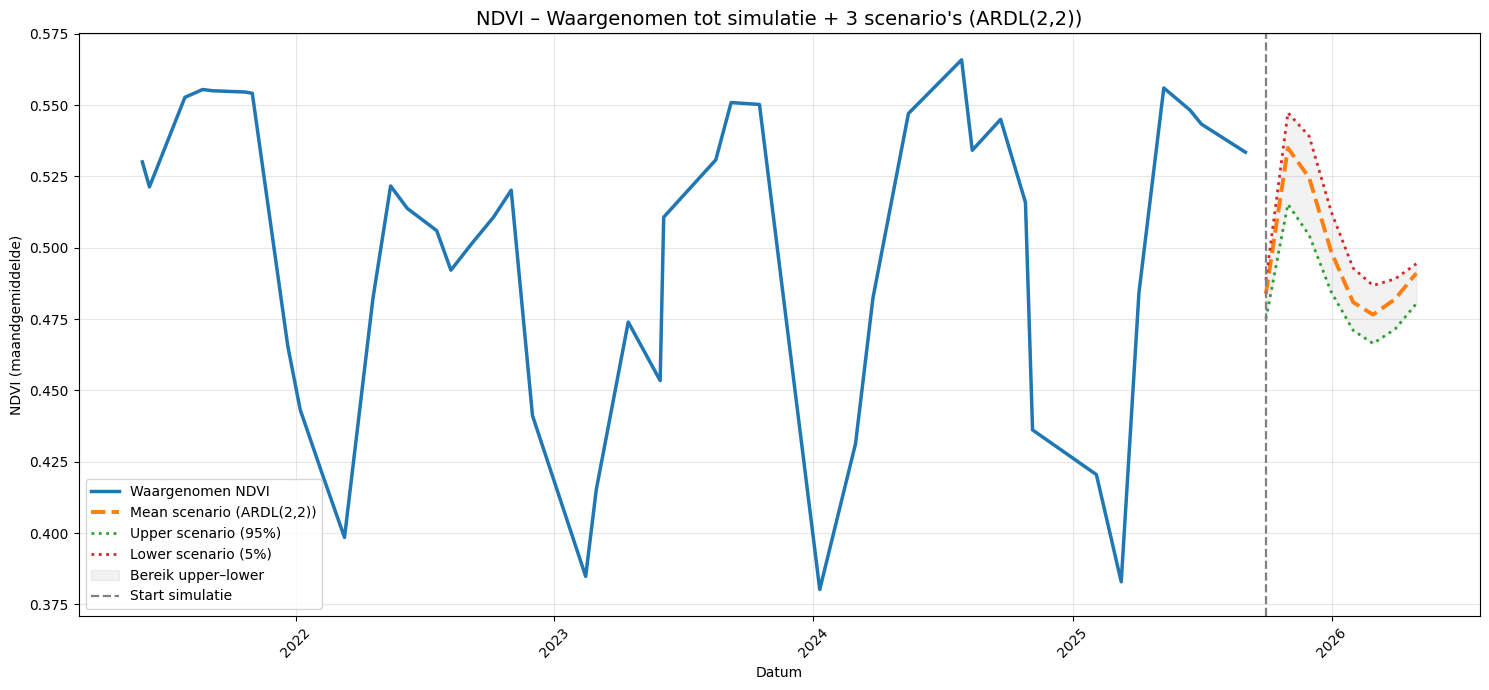


Laatste 6 maanden voorspelling – ARDL(2,2)


,date,ndvi_mean,ndvi_upper,ndvi_lower
2,2025-11-30,0.5245,0.5044,0.5391
3,2025-12-31,0.4987,0.4845,0.5127
4,2026-01-31,0.4809,0.4710,0.4928
5,2026-02-28,0.4766,0.4665,0.4868
6,2026-03-31,0.4820,0.4715,0.4891
7,2026-04-30,0.4911,0.4804,0.4944


In [20]:
# ────────────────────────────────────────────────
#  NDVI voorspellen PER SCENARIO + plot met 3 lijnen
#  Waargenomen NDVI stopt bij start simulatie
# ────────────────────────────────────────────────
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# ================================================
# Welk model wil je gebruiken?
# ================================================
model_choice = "ARDL(2,2)"          # Voorbeelden: "linear", "koyck", "ARDL(1,1)", "ARDL(2,2)", "ARDL(3,3)"

# ================================================
# Maandelijkse GW forecast voorbereiden
# ================================================
df_forecast_month = df_forecast.resample("ME").mean(numeric_only=True)
df_forecast_month["date"] = df_forecast_month.index
df_forecast_month = df_forecast_month.reset_index(drop=True)

# Startdatum van de simulatie/forecast
forecast_start = df_forecast_month["date"].min()

# ================================================
# Model selecteren
# ================================================
model = None
use_lagged_ndvi = False
p, q = 0, 0

if model_choice == "linear":
    model = ols_model
    use_lagged_ndvi = False
    print("→ Linear regression (OLS)")

elif model_choice == "koyck":
    model = koyck_model
    use_lagged_ndvi = True
    p, q = 1, 1   # koyck ≈ ARDL(1,1)
    print("→ Koyck model")

elif model_choice.startswith("ARDL("):
    try:
        p_str, q_str = model_choice.replace("ARDL(", "").replace(")", "").split(",")
        p = int(p_str.strip())
        q = int(q_str.strip())
        
        for pp, qq, m in results:
            if pp == p and qq == q:
                model = m
                break
        
        if model is None:
            raise ValueError(f"ARDL({p},{q}) niet gevonden in results")
        
        use_lagged_ndvi = True
        print(f"→ ARDL({p},{q})")
        
    except Exception as e:
        print(f"Fout bij ARDL: {e}")
        raise

else:
    raise ValueError("Onbekend model. Gebruik 'linear', 'koyck' of 'ARDL(p,q)'")

# ================================================
# Drie scenario's voorspellen
# ================================================
scenarios = ["mean", "upper", "lower"]
ndvi_preds = {}

for scen in scenarios:
    print(f"Voorspellen scenario: {scen}")
    
    if not use_lagged_ndvi:
        # Directe voorspelling (alleen bij linear model)
        gw_col = "gw_mean_sim" if scen == "mean" else f"gw_{scen}_95" if scen == "upper" else "gw_lower_5"
        X_scen = sm.add_constant(df_forecast_month[gw_col])
        ndvi_preds[scen] = model.predict(X_scen)
    
    else:
        # Recursieve voorspelling PER SCENARIO
        forecast_ndvi = []
        
        # Start met historische waarden (zelfde voor alle scenario's)
        ndvi_history = list(df_month["ndvi_month"].tail(max(p,1)).values[::-1])
        gw_history   = list(df_month["gw_month"].tail(max(q,1)).values[::-1])
        
        gw_col = "gw_mean_sim" if scen == "mean" else f"gw_{scen}_95" if scen == "upper" else "gw_lower_5"
        
        for i, row in df_forecast_month.iterrows():
            X_dict = {"const": 1.0}
            
            current_gw = row[gw_col]
            X_dict["gw_month"] = current_gw
            
            # GW lags
            for lag in range(1, q+1):
                val = gw_history[lag-1] if len(gw_history) >= lag else df_month["gw_month"].iloc[-1]
                X_dict[f"gw_lag{lag}"] = val
            
            # NDVI lags (uit dit scenario)
            for lag in range(1, p+1):
                val = ndvi_history[lag-1] if len(ndvi_history) >= lag else df_month["ndvi_month"].iloc[-1]
                X_dict[f"ndvi_lag{lag}"] = val
            
            X_row = pd.DataFrame([X_dict])
            pred = model.predict(X_row)[0]
            forecast_ndvi.append(pred)
            
            ndvi_history.insert(0, pred)
            gw_history.insert(0, current_gw)
        
        ndvi_preds[scen] = forecast_ndvi

# Resultaten toevoegen aan dataframe
df_forecast_month["ndvi_mean"]  = ndvi_preds["mean"]
df_forecast_month["ndvi_upper"] = ndvi_preds["upper"]
df_forecast_month["ndvi_lower"] = ndvi_preds["lower"]

# ================================================
# Plot: waargenomen NDVI alleen vóór simulatie
# ================================================
fig, ax = plt.subplots(figsize=(15, 7))

# Historische NDVI – alleen tot forecast start
hist_mask = df_month["date"] < forecast_start   # of <= als je de laatste maand wel wilt zien
ax.plot(df_month.loc[hist_mask, "date"],
        df_month.loc[hist_mask, "ndvi_month"],
        color='#1f77b4', linewidth=2.5, label='Waargenomen NDVI')

# Voorspelde lijnen – alleen in forecast-periode
fc_mask = df_forecast_month["date"] >= forecast_start

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_mean"],
        color='#ff7f0e', linewidth=2.8, linestyle='--', label=f'Mean scenario ({model_choice})')

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_upper"],
        color='#2ca02c', linewidth=2.0, linestyle=':', label='Upper scenario (95%)')

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_lower"],
        color='#d62728', linewidth=2.0, linestyle=':', label='Lower scenario (5%)')

# Band alleen in forecast-periode
ax.fill_between(df_forecast_month.loc[fc_mask, "date"],
                df_forecast_month.loc[fc_mask, "ndvi_lower"],
                df_forecast_month.loc[fc_mask, "ndvi_upper"],
                color='gray', alpha=0.10, label='Bereik upper–lower')

# Scheidingslijn
ax.axvline(forecast_start, color='gray', linestyle='--', linewidth=1.6,
           label='Start simulatie')

ax.set_ylabel("NDVI (maandgemiddelde)")
ax.set_xlabel("Datum")
ax.set_title(f"NDVI – Waargenomen tot simulatie + 3 scenario's ({model_choice})", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Laatste paar voorspellingen tonen
print(f"\nLaatste 6 maanden voorspelling – {model_choice}")
display(df_forecast_month[["date", "ndvi_mean", "ndvi_upper", "ndvi_lower"]].tail(6).round(4))

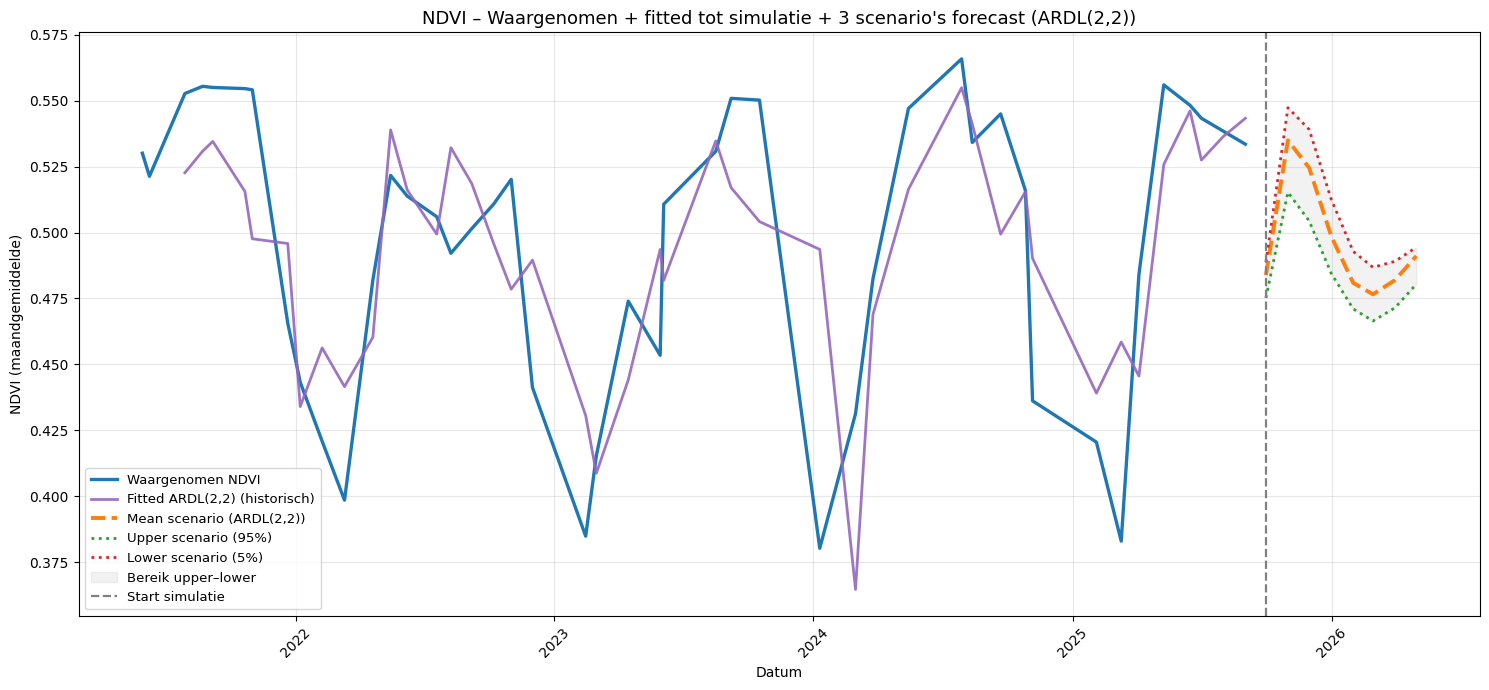

In [21]:
# ────────────────────────────────────────────────
#  Plot: waargenomen NDVI + fitted values historisch (tot simulatie-start)
#        + 3 scenario's forecast
# ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))

# Maskers
hist_mask = df_month["date"] < forecast_start
fc_mask   = df_forecast_month["date"] >= forecast_start

# 1. Waargenomen NDVI – alleen historisch, tot forecast start
ax.plot(df_month.loc[hist_mask, "date"],
        df_month.loc[hist_mask, "ndvi_month"],
        color='#1f77b4', linewidth=2.4, label='Waargenomen NDVI')

# 2. Fitted values historisch – ook alleen tot forecast start
if not use_lagged_ndvi:
    # Lineair model: predict over hele df_month, maar slice op hist_mask
    X_hist = sm.add_constant(df_month["gw_month"])
    fitted_hist = model.predict(X_hist)
    ax.plot(df_month.loc[hist_mask, "date"],
            fitted_hist[hist_mask],
            color='#9467bd', linewidth=2.0, linestyle='-', alpha=0.9,
            label=f'Fitted {model_choice} (historisch)')

else:
    # ARDL / Koyck: probeer fittedvalues te gebruiken + slice
    if hasattr(model, 'fittedvalues'):
        fitted_hist = model.fittedvalues
        # fittedvalues heeft vaak kortere lengte (door lags), dus aligneren op laatste waarden
        fitted_dates = df_month["date"].iloc[-len(fitted_hist):]
        # Alleen plotten tot forecast_start
        fit_mask = fitted_dates < forecast_start
        ax.plot(fitted_dates[fit_mask],
                fitted_hist[fit_mask],
                color='#9467bd', linewidth=2.0, linestyle='-', alpha=0.9,
                label=f'Fitted {model_choice} (historisch)')
    else:
        print("Waarschuwing: fittedvalues niet direct beschikbaar → geen paarse lijn")
        # fallback: predict op historische data (kan je later uitbreiden)

# 3. Voorspelde lijnen – alleen in forecast-periode
ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_mean"],
        color='#ff7f0e', linewidth=2.8, linestyle='--', label=f'Mean scenario ({model_choice})')

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_upper"],
        color='#2ca02c', linewidth=2.0, linestyle=':', label='Upper scenario (95%)')

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_lower"],
        color='#d62728', linewidth=2.0, linestyle=':', label='Lower scenario (5%)')

# Band alleen in forecast-periode
ax.fill_between(df_forecast_month.loc[fc_mask, "date"],
                df_forecast_month.loc[fc_mask, "ndvi_lower"],
                df_forecast_month.loc[fc_mask, "ndvi_upper"],
                color='gray', alpha=0.10, label='Bereik upper–lower')

# Verticale lijn
ax.axvline(forecast_start, color='gray', linestyle='--', linewidth=1.6,
           label='Start simulatie')

ax.set_ylabel("NDVI (maandgemiddelde)")
ax.set_xlabel("Datum")
ax.set_title(f"NDVI – Waargenomen + fitted tot simulatie + 3 scenario's forecast ({model_choice})", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()